<a href="https://colab.research.google.com/github/dishidhak/DS3021assignments/blob/main/05_dd_glm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Latent Variable Models (Logistic Regression)

## Foundations of Machine Learning

### Dishitha Dhakshin (qxk8wp)

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?

They allow us to model outcomes that aren’t continuous and handle nonlinear relationships through transformations. They also ensure predictions make sense (like probabilities between 0 and 1), which regular linear models cannot guarantee.

2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.

Cross entropy measures how close predicted probabilities are to the true labels and strongly penalizes confident incorrect predictions. This encourages the model to produce accurate probability estimates, which is exactly what logistic regression aims to do.


3. True or false, and explain: Logistic regression is a linear model.

True. It is linear in the coefficients because it models a linear combination of inputs, but applies a nonlinear function (sigmoid) to convert that into probabilities.

4. True or false, and explain: Logistic regression cannot be used for classification.

False. Logistic regression is commonly used for classification by predicting probabilities and assigning classes based on a threshold (e.g., 0.5).

5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?

No. The coefficient represents the change in the log-odds of the outcome, not the direct change in probability, which is nonlinear.


6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.

False. Logistic regression is linear in the features, so it cannot capture complex relationships unless we add engineered features like interactions or polynomial terms.


7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

False. Logistic regression is better for classification problems, while linear regression is better for predicting continuous outcomes. The choice depends on the task.

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


In [1]:
! git clone https://github.com/ds4e/undergrad_ml_assignments

Cloning into 'undergrad_ml_assignments'...
remote: Enumerating objects: 129, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 129 (delta 1), reused 0 (delta 0), pack-reused 126 (from 3)
Receiving objects: 100% (129/129), 12.44 MiB | 15.24 MiB/s, done.
Resolving deltas: 100% (46/46), done.


In [6]:
# 2.1
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv('./undergrad_ml_assignments/data/data.csv', sep=';')
df.head()

df.columns


Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance\t', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd

In [7]:
df['Target'].value_counts()

,count
Target,
Graduate,2209
Dropout,1421
Enrolled,794


In [8]:
df = df[['Debtor', 'Tuition fees up to date', 'Scholarship holder',
         'Age at enrollment', 'Curricular units 1st sem (approved)',
         'Target']]
df.head()

,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,Curricular units 1st sem (approved),Target
0,0,1,0,20,0,Dropout
1,0,0,0,19,6,Graduate
2,0,0,0,19,0,Dropout
3,0,1,0,20,6,Graduate
4,0,1,0,45,5,Graduate


In [9]:
# 2.2
from sklearn.linear_model import LogisticRegression

x = df.drop(['Curricular units 1st sem (approved)', 'Target' ], axis=1)
y = df[['Target']]

logreg = LogisticRegression(
    solver='lbfgs',
    max_iter=5000,
    multi_class='multinomial'
)

logreg = logreg.fit(x, y)

mnl_coef = pd.DataFrame(logreg.coef_ , index=logreg.classes_)
mnl_coef = mnl_coef.set_axis(logreg.feature_names_in_,axis=1)
mnl_coef

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment
Dropout,0.309030,-1.682221,-0.633771,0.033086
Enrolled,0.269880,0.316375,-0.242308,-0.016066
Graduate,-0.578911,1.365846,0.876080,-0.017020


On average, being up to date on tuition changes the predicted probability of dropout by 0.32121844680263767%


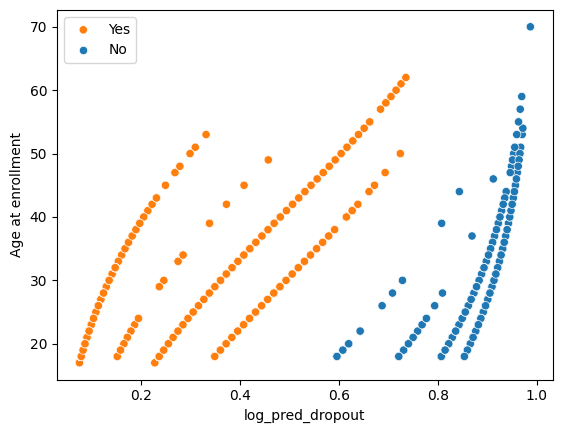

In [10]:
# 2.3
probs = logreg.predict_proba(x)
df['log_pred_dropout'] = probs[:, [0]]

sns.scatterplot(df, x = 'log_pred_dropout', y = 'Age at enrollment', hue = 'Tuition fees up to date' )
plt.legend(['Yes', 'No'])
print(f'On average, being up to date on tuition changes the predicted probability of dropout by {df['log_pred_dropout'].mean()}%')

In [11]:
# 2.4
tab = pd.crosstab(logreg.predict(x), df['Target'])
tab

Target,Dropout,Enrolled,Graduate
row_0,,,
Dropout,659,146,194
Graduate,762,648,2015


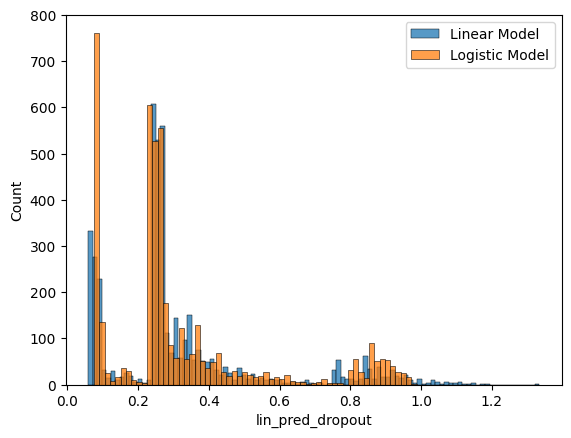

In [12]:
# 2.5
from sklearn.linear_model import LinearRegression

x = df.drop(['Curricular units 1st sem (approved)', 'Target', 'log_pred_dropout'], axis=1)
y_prob_dropout = df['log_pred_dropout']

linreg = LinearRegression()

linreg = linreg.fit(x, y_prob_dropout)
df['lin_pred_dropout'] = linreg.predict(x)

sns.histplot(data = df, x = 'lin_pred_dropout', label='Linear Model')
sns.histplot(data = df, x = 'log_pred_dropout', label='Logistic Model')

plt.legend()

In scanning the histogram above, we can see that the logistic and linear models have very similar predictions, except for at around 10% where the logisitic model predicts a much higher count than the linear model.

### 2.6
The students that are most at-risk of dropping out are those that have outstanding debt, and those least at-risk are students with scholarships. So, an effective intervention would be offering more scholarship opportunities.


In [14]:
# 2.7
x = df[['Debtor', 'Tuition fees up to date', 'Curricular units 1st sem (approved)']]
y = df['Target']

logreg = LogisticRegression(
    solver='lbfgs',
    max_iter=5000,
    multi_class='multinomial'
)

logreg = logreg.fit(x, y)

df['log_hard_class'] = logreg.predict(x)
tab = pd.crosstab(df['log_hard_class'], df['Target'])
print(tab)

true = tab.loc['Dropout', 'Dropout'] + tab.loc['Graduate', 'Graduate']
total = tab.values.sum()
accuracy = true/total
print(f'The accuracy of the hard classification is {accuracy}.')

print(logreg.classes_[0]) #dropout
print(logreg.classes_[1]) #enrollment
print(logreg.classes_[2]) #graduated


df['prob_log_drop'] = logreg.predict_proba(x)[:, 0]
df['prob_log_enroll'] = logreg.predict_proba(x)[:, 1]
df['prob_log_grad'] = logreg.predict_proba(x)[:, 2]

print(f'average probability prediction of dropout is {df['prob_log_drop'].mean()}')
print(f'average probability prediction of enrollment is {df['prob_log_enroll'].mean()}')
print(f'average probability prediction of graduated is {df['prob_log_grad'].mean()}')

df[['prob_log_drop', 'prob_log_enroll', 'prob_log_grad']]

Target          Dropout  Enrolled  Graduate
log_hard_class                             
Dropout            1054       280       146
Graduate            367       514      2063
The accuracy of the hard classification is 0.7045660036166366.
Dropout
Enrolled
Graduate
average probability prediction of dropout is 0.32122294188826644
average probability prediction of enrollment is 0.17947367985866028
average probability prediction of graduated is 0.4993033782530733


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,prob_log_drop,prob_log_enroll,prob_log_grad
0,0.680547,0.210464,0.108989
1,0.695414,0.146043,0.158543
2,0.952988,0.041199,0.005813
3,0.117808,0.176983,0.705209
4,0.184227,0.212669,0.603104
...,...,...,...
4419,0.184227,0.212669,0.603104
4420,0.784988,0.149758,0.065253
4421,0.071938,0.140644,0.787418
4422,0.184227,0.212669,0.603104


**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

In [19]:
# 3.1
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import confusion_matrix, accuracy_score

df = pd.read_csv('./undergrad_ml_assignments/data/cirrhosis.csv')

cols = ['Status', 'Edema', 'Drug', 'Bilirubin', 'Stage']
cirr = df[cols].copy()

cirr = cirr[cirr['Status'].isin(['C', 'CL', 'D'])].copy()
cirr['Status_bin'] = cirr['Status'].replace({'C': 1, 'CL': 1, 'D': 0})

cirr = cirr.dropna(subset=['Status_bin', 'Edema', 'Drug', 'Bilirubin', 'Stage'])

print(cirr.head())
print(cirr.isna().sum())
print(cirr.shape)

  Status Edema             Drug  Bilirubin  Stage  Status_bin
0      D     Y  D-penicillamine       14.5    4.0           0
1      C     N  D-penicillamine        1.1    3.0           1
2      D     S  D-penicillamine        1.4    4.0           0
3      D     S  D-penicillamine        1.8    4.0           0
4     CL     N          Placebo        3.4    3.0           1
Status        0
Edema         0
Drug          0
Bilirubin     0
Stage         0
Status_bin    0
dtype: int64
(312, 6)


/tmp/ipykernel_2889/4187040961.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cirr['Status_bin'] = cirr['Status'].replace({'C': 1, 'CL': 1, 'D': 0})


In [20]:
# 3.2
X = pd.get_dummies(cirr[['Edema', 'Drug', 'Bilirubin']], drop_first=True)
y = cirr['Status_bin']

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X, y)

coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Coefficient': logreg.coef_[0]
})

print(coef_df)
print("Intercept:", logreg.intercept_[0])

       Variable  Coefficient
0     Bilirubin    -0.351424
1       Edema_S    -0.450677
2       Edema_Y    -1.611049
3  Drug_Placebo     0.231225
Intercept: 1.3798277993022918


The coefficient for bilirubin is negative, indicating that higher bilirubin levels are associated with lower survival probability. Both edema categories have negative coefficients relative to no edema, with persistent edema (Edema_Y) showing a much stronger decrease in survival than mild edema (Edema_S). The positive coefficient for Drug_Placebo indicates that patients on placebo have higher predicted survival than those on D-penicillamine, suggesting the drug does not improve survival. Overall, worse clinical indicators (especially high bilirubin and severe edema) are associated with lower survival rates.

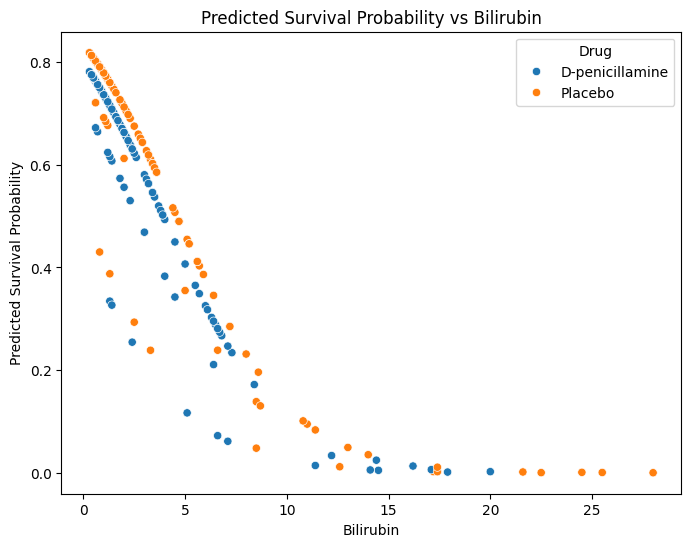

In [21]:
# 3.3
# Predicted survival probabilities
cirr['pred_survival_prob'] = logreg.predict_proba(X)[:, 1]

# Scatter plot
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=cirr,
    x='Bilirubin',
    y='pred_survival_prob',
    hue='Drug'
)
plt.title('Predicted Survival Probability vs Bilirubin')
plt.xlabel('Bilirubin')
plt.ylabel('Predicted Survival Probability')
plt.show()

The scatter plot shows that predicted survival probability decreases as bilirubin increases for both treatment groups. Across nearly all bilirubin values, patients receiving placebo have consistently higher predicted survival probabilities than those receiving D-penicillamine. This suggests that the drug does not improve survival at any range of bilirubin and may slightly worsen outcomes. Overall, the effect of the drug appears negative, with patients on the drug having lower predicted survival probabilities on average.

In [22]:
# 3.4
# Predictions
y_pred = logreg.predict(X)

# Confusion matrix
cm = confusion_matrix(y, y_pred)
print("Confusion Matrix:\n", cm)

# Accuracy
acc = accuracy_score(y, y_pred)
print("Accuracy:", acc)

Confusion Matrix:
 [[ 59  66]
 [ 16 171]]
Accuracy: 0.7371794871794872


The confusion matrix shows that the model correctly classifies many observations, with 171 true positives and 59 true negatives, but also makes some errors, including 66 false positives and 16 false negatives. This indicates the model is better at predicting survival than death. The overall accuracy is approximately 0.737, meaning about 73.7% of patients are correctly classified. Overall, the model provides a reasonably good prediction of survival outcomes, though some misclassification remains.

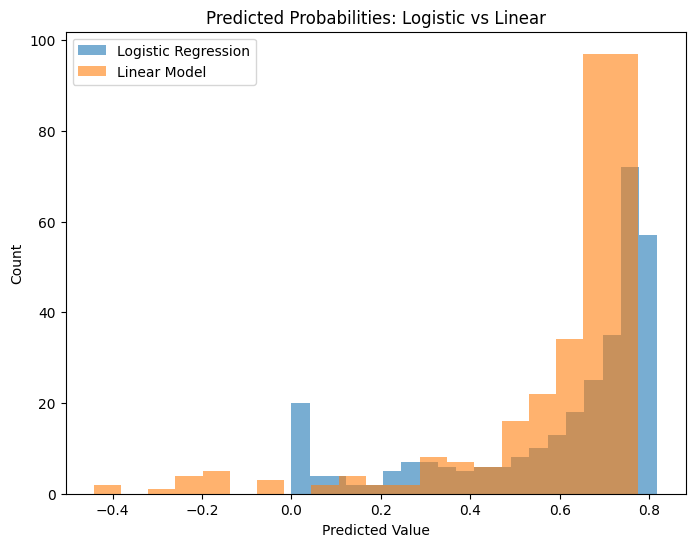

Logistic Accuracy: 0.7371794871794872
Linear Accuracy: 0.7211538461538461


In [23]:
# 3.5
# Linear model
linreg = LinearRegression()
linreg.fit(X, y)

# Predicted probabilities
cirr['lin_pred'] = linreg.predict(X)

# Histogram comparison
plt.figure(figsize=(8,6))
plt.hist(cirr['pred_survival_prob'], bins=20, alpha=0.6, label='Logistic Regression')
plt.hist(cirr['lin_pred'], bins=20, alpha=0.6, label='Linear Model')
plt.xlabel('Predicted Value')
plt.ylabel('Count')
plt.title('Predicted Probabilities: Logistic vs Linear')
plt.legend()
plt.show()

# Accuracy comparison (using 0.5 cutoff for linear model)
lin_pred_class = (cirr['lin_pred'] >= 0.5).astype(int)
lin_acc = accuracy_score(y, lin_pred_class)

print("Logistic Accuracy:", acc)
print("Linear Accuracy:", lin_acc)

The histogram shows that logistic regression produces predicted probabilities strictly between 0 and 1, while the linear model produces some values outside this range, including negative values. This makes the logistic model more appropriate for interpreting predictions as probabilities. In terms of performance, logistic regression has slightly higher accuracy (0.737) compared to the linear model (0.721). Overall, logistic regression provides both more meaningful probability estimates and slightly better predictive performance.

In [24]:
# 3.6
# Features and target
X_stage = pd.get_dummies(cirr[['Edema', 'Bilirubin']], drop_first=True)
y_stage = cirr['Stage'].astype(int)

# Multinomial logistic regression
stage_model = LogisticRegression(multi_class='multinomial', max_iter=1000)
stage_model.fit(X_stage, y_stage)

# Hard predictions
stage_pred = stage_model.predict(X_stage)

# Confusion matrix
stage_cm = confusion_matrix(y_stage, stage_pred)
print("Confusion Matrix:\n", stage_cm)

# Predicted classes
print("Classes predicted:", np.unique(stage_pred))

# Probabilities
stage_probs = stage_model.predict_proba(X_stage)
print("Classes in predict_proba:", stage_model.classes_)
print(stage_probs[:5])

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Confusion Matrix:
 [[  0   0  16   0]
 [  0   0  63   4]
 [  0   0 105  15]
 [  0   0  79  30]]
Classes predicted: [3 4]
Classes in predict_proba: [1 2 3 4]
[[1.28550372e-05 3.25351316e-02 1.43611431e-01 8.23840583e-01]
 [7.23937578e-02 2.51555267e-01 3.97519699e-01 2.78531276e-01]
 [2.92626485e-02 1.81530850e-01 3.95694470e-01 3.93512032e-01]
 [2.32719781e-02 1.76777228e-01 3.97216502e-01 4.02734292e-01]
 [2.02038998e-02 2.24965391e-01 4.23342268e-01 3.31488440e-01]]


The confusion matrix shows that the model performs poorly as a hard classifier because it only predicts stages 3 and 4, and never predicts stages 1 or 2. This means the hard classification does not predict every class. However, the predict_proba output gives probabilities for all four classes (1, 2, 3, and 4) for each observation. So while the model’s final class predictions are limited, its probability estimates still account for every stage.

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?


2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?


3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?

Work done on paper, here! ---> https://drive.google.com/file/d/1Wl8-SYhmF87yZLeH4TSWSnIc_c0mmEmB/view?usp=sharing
